<a href="https://colab.research.google.com/github/Ammar-creator-cmd/DataVisualization/blob/main/Rainfall_Investigation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Data Collection


In [1]:
import pandas as pd
file_id = '1ha6-YJq02MBaSPgTSPg3kTqXNI0TYzqi'
url = 'https://drive.google.com/uc?id={}'.format(file_id)
data = pd.read_csv(url)

### Data processing

In [2]:
data.head()

,DATE,PRCP,TMAX,TMIN,RAIN
0,1948-01-01,0.47,51,42,True
1,1948-01-02,0.59,45,36,True
2,1948-01-03,0.42,45,35,True
3,1948-01-04,0.31,45,34,True
4,1948-01-05,0.17,45,32,True


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25551 entries, 0 to 25550
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   DATE    25551 non-null  object 
 1   PRCP    25548 non-null  float64
 2   TMAX    25551 non-null  int64  
 3   TMIN    25551 non-null  int64  
 4   RAIN    25548 non-null  object 
dtypes: float64(1), int64(2), object(2)
memory usage: 998.2+ KB


In [4]:
data.describe()

,PRCP,TMAX,TMIN
count,25548.000000,25551.000000,25551.000000
mean,0.106222,59.544206,44.514226
std,0.239031,12.772984,8.892836
min,0.000000,4.000000,0.000000
25%,0.000000,50.000000,38.000000
50%,0.000000,58.000000,45.000000
75%,0.100000,69.000000,52.000000
max,5.020000,103.000000,71.000000


In [5]:
data.isnull().sum()

,0
DATE,0
PRCP,3
TMAX,0
TMIN,0
RAIN,3


In [6]:
data.dropna(inplace=True)

In [7]:
data.isnull().sum()

,0
DATE,0
PRCP,0
TMAX,0
TMIN,0
RAIN,0


In [8]:
data.duplicated().sum()

np.int64(0)

### Data Formatting

In [9]:
#Changing columns to necessary data types
data = data.astype({"DATE" : "datetime64[ns]", "RAIN" : "int16"})

In [10]:
data.head()

,DATE,PRCP,TMAX,TMIN,RAIN
0,1948-01-01,0.47,51,42,1
1,1948-01-02,0.59,45,36,1
2,1948-01-03,0.42,45,35,1
3,1948-01-04,0.31,45,34,1
4,1948-01-05,0.17,45,32,1


### Exploratory Data Analysis

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

In [12]:
#extract the MONTH from the DATE column and create a new month column
data["MONTH"] = data["DATE"].dt.month

#create aa pivot table
rainfall_pivot = data.pivot_table(index = ["RAIN"], columns = "MONTH", aggfunc = "size", fill_value = 0)

#select the row where RAIN is true
rainymonth_counter = rainfall_pivot.loc[1]

#extract the keys (months) and values (counters)
months = rainymonth_counter.index
counter = rainymonth_counter.values

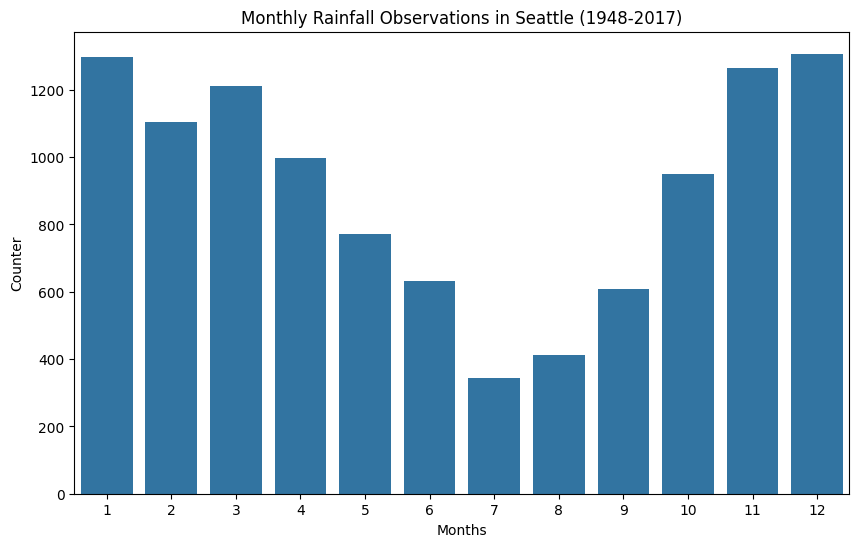

In [13]:
#create a bar plot using sns
plt.figure(figsize = (10, 6))
sns.barplot(x = months, y = counter)
plt.xlabel("Months")
plt.ylabel("Counter")
plt.title("Monthly Rainfall Observations in Seattle (1948-2017)")
plt.show()

Monthly Precipitation

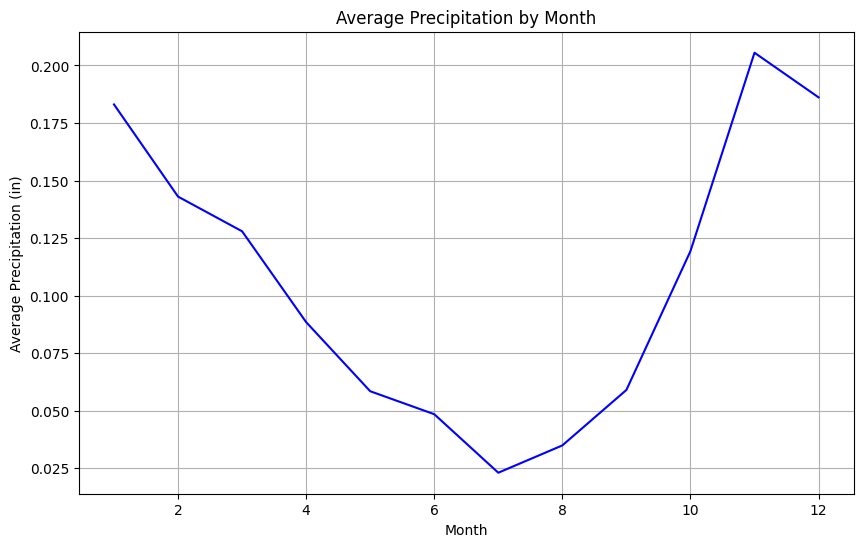

In [14]:
averageByMonth = data.groupby("MONTH")["PRCP"].mean().reset_index()
plt.figure(figsize=(10, 6))
sns.lineplot(data=averageByMonth, x='MONTH', y='PRCP', linewidth=1.5, color='blue')
plt.title('Average Precipitation by Month')
plt.xlabel('Month')
plt.ylabel('Average Precipitation (in)')
plt.grid(True)
plt.show()

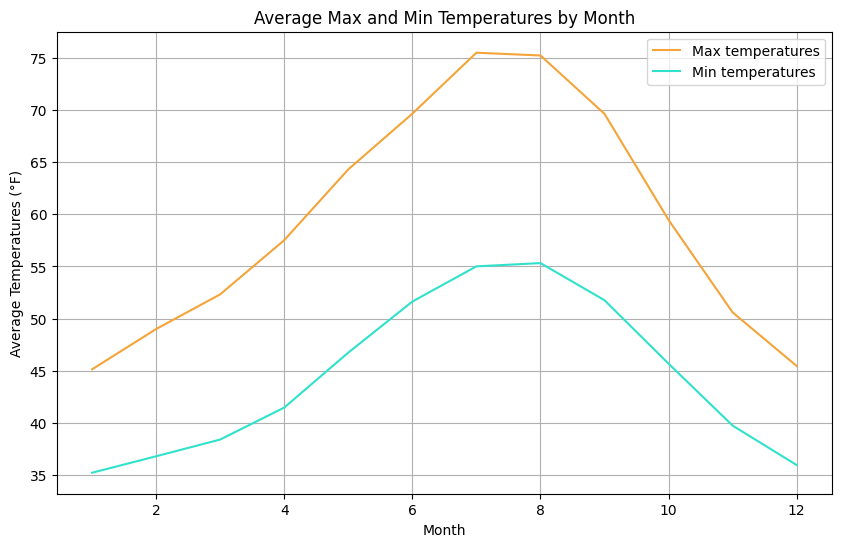

In [15]:
# Calculate the average maximum and minimum temperatures by month
averageByMonth = data.groupby('MONTH')[['TMAX', 'TMIN']].mean().reset_index()
# Create a line plot using Seaborn and Matplotlib
plt.figure(figsize=(10, 6))
sns.lineplot(data=averageByMonth, x='MONTH', y='TMAX', linewidth=1.5, color='#F4A438', label='Max temperatures')
sns.lineplot(data=averageByMonth, x='MONTH', y='TMIN', linewidth=1.5, color='#30E1CB', label='Min temperatures')
plt.title('Average Max and Min Temperatures by Month')
plt.xlabel('Month')
plt.ylabel('Average Temperatures (°F)')
plt.legend()
plt.grid(True)
plt.show()

In [16]:
#convert "date" to a datetime object
data["DATE"] = pd.to_datetime(data["DATE"])

data["YEAR"] = data["DATE"].dt.year

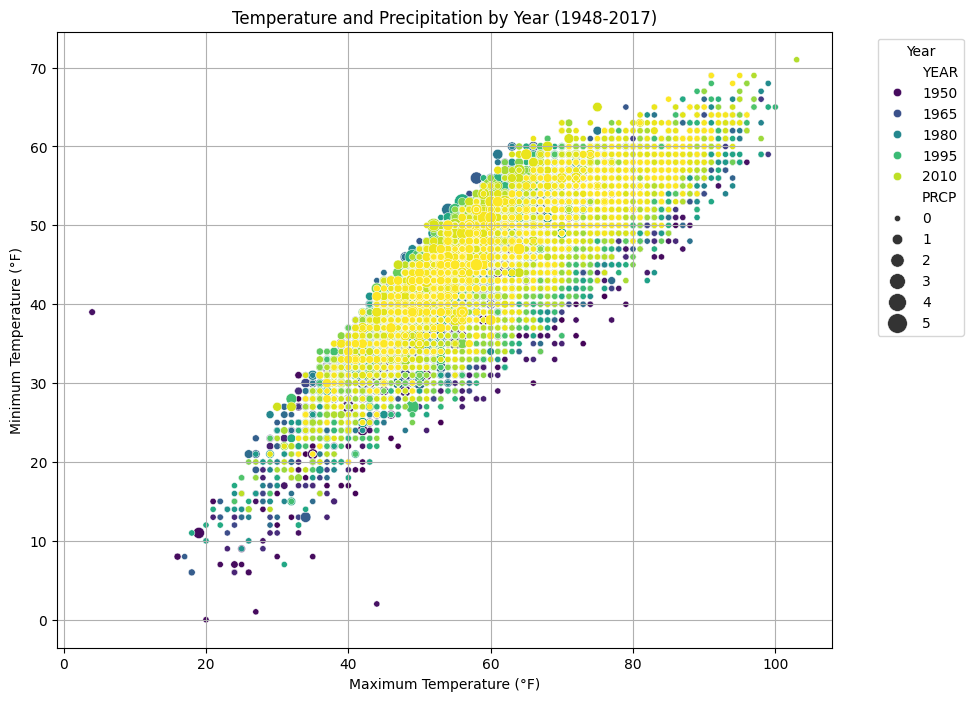

In [17]:
#create a scatter plot using seaborn and plt
plt.figure(figsize = (10, 8))
sns.scatterplot(data = data, x = "TMAX", y = "TMIN", hue = "YEAR", size = "PRCP", sizes = (20, 200), palette = "viridis")
plt.title("Temperature and Precipitation by Year (1948-2017)")
plt.xlabel('Maximum Temperature (°F)')
plt.ylabel('Minimum Temperature (°F)')
plt.legend(title='Year', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.show()

Calculation of average yearly precipitation

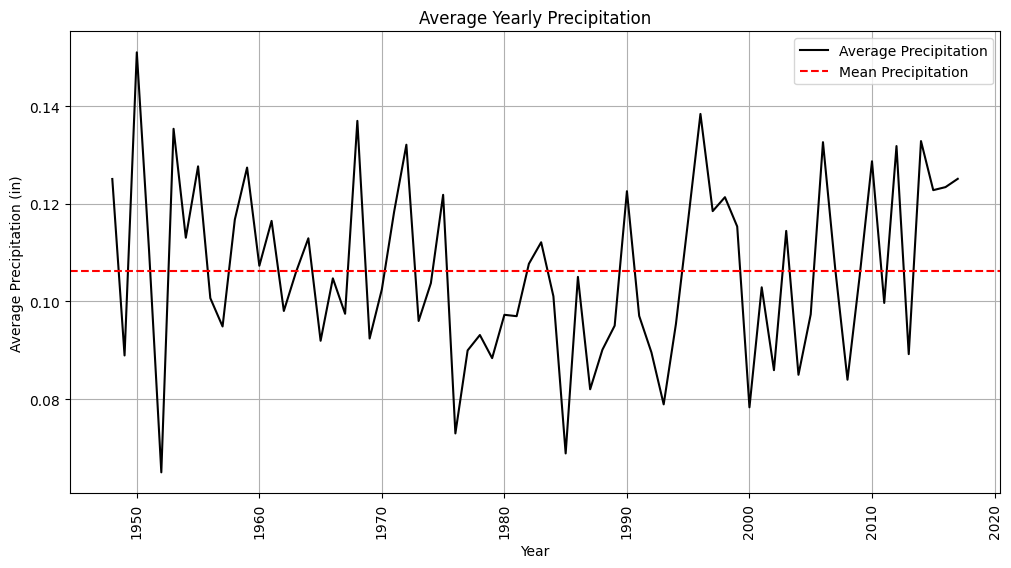

In [18]:
# Calculate average yearly precipitation
averageByYear = data.groupby('YEAR')['PRCP'].mean().reset_index()
# Create the plot
plt.figure(figsize=(12, 6))
sns.lineplot(data=averageByYear, x='YEAR', y='PRCP', linewidth=1.5, color='black', label='Average Precipitation')
plt.axhline(y=averageByYear['PRCP'].mean(), linestyle='dashed', color='red', label='Mean Precipitation')
plt.title('Average Yearly Precipitation')
plt.xlabel('Year')
plt.ylabel('Average Precipitation (in)')
plt.xticks(rotation=90)
plt.grid(True)
plt.legend()
plt.show()

### Feature Engineering

In [19]:
# Convert the 'DATE' column into a float data type
data['DATE'] = pd.to_datetime(data['DATE']).astype(int) / 10**9  # Convert to seconds
# Check the data type of the 'DATE' column
print(data['DATE'].dtype)

float64


### Features and Target

In [20]:
#separate features (predictions) and target variable
features = data[["DATE", "PRCP", "TMAX", "TMIN"]]

target = data["RAIN"]

### Data Splitting

In [21]:
from sklearn.model_selection import train_test_split
# Split the data into training and testing sets (e.g., 80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)
# Print the shapes of the training and testing sets for verification
print("Training set - Features:", X_train.shape, " Target:", y_train.shape)
print("Testing set - Features:", X_test.shape, " Target:", y_test.shape)

Training set - Features: (20438, 4)  Target: (20438,)
Testing set - Features: (5110, 4)  Target: (5110,)


### Model Training

Training a Logistic Regression Model:

In [22]:
from sklearn.linear_model import LogisticRegression

#Initialize the logistic regression model
logistic_regression_model = LogisticRegression(random_state = 42)

#Train the model on the training data
logistic_regression_model.fit(X_train, y_train)

LogisticRegression(random_state=42)

### Training a Decision Tree Model

In [23]:
from sklearn.tree import DecisionTreeClassifier
# Initialize the decision tree classifier model
decision_tree_model = DecisionTreeClassifier(random_state=42)
# Train the model on the training data
decision_tree_model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

### Evaluating Model

logistic_regression_model



In [25]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [27]:
y_pred_logistic = logistic_regression_model.predict(X_test)

In [28]:
mae_logistic = mean_absolute_error(y_test, y_pred_logistic)
mse_logistic = mean_squared_error(y_test, y_pred_logistic)
r2_logistic = r2_score(y_test, y_pred_logistic)

In [36]:
print("mae_logistic : ", mae_logistic)
print("mse_logistic : ", mse_logistic)
print("r2_logistic : ", r2_logistic)

mae_logistic :  0.42211350293542077
mse_logistic :  0.42211350293542077
r2_logistic :  -0.7304436166610231


In [37]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
y_pred_decision_tree = decision_tree_model.predict(X_test)

In [38]:
mae_decision_tree = mean_absolute_error(y_test, y_pred_decision_tree)
mse_decision_tree = mean_squared_error(y_test, y_pred_decision_tree)
r2_decision_tree = r2_score(y_test, y_pred_decision_tree)

In [39]:
print("mae_decision_tree : ", mae_decision_tree)
print("mse_decision_tree : ", mse_decision_tree)
print("r2_decision_tree : ", r2_decision_tree)

mae_decision_tree :  0.0
mse_decision_tree :  0.0
r2_decision_tree :  1.0


### Prediction

In [57]:
# Create a new data point for prediction
new_data_point = pd.DataFrame({
    'DATE': ['2026-04-11'],  # Replace with your desired date
    'PRCP': [0.2],           # Replace with your precipitation value
    'TMAX': [31],            # Replace with your maximum temperature value
    'TMIN': [23]             # Replace with your minimum temperature value
})

In [58]:
new_data_point['DATE'] = pd.to_datetime(new_data_point['DATE']).astype(int) / 10**9 #astype to change data types to other types

In [59]:
prediction = decision_tree_model.predict(new_data_point)

In [60]:
print("Predicted RAIN", prediction[0])

Predicted RAIN 1
